<a href="https://www.kaggle.com/code/sonawanelalitsunil/md-simulation-results-analysis-ml-100?scriptVersionId=272670807" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/md-simulation-results/host_hybrid.csv
/kaggle/input/md-simulation-results/PI1M_hybrid_09_07.csv
/kaggle/input/md-simulation-results/PI1M_hybrid_09_13.csv


## Title: MD Simulation Results Analysis

## Description:
This dataset contains detailed molecular dynamics (MD) simulation results for various polymer systems. It includes structural, volumetric, and dynamic properties such as density, free volume fraction, voxel counts, radius of gyration, asphericity, persistence lengths, diffusivity, and monomer/homopolymer shape descriptors. The data allows for exploring correlations between molecular structure and dynamic behavior, providing insights into polymer properties and their potential applications in materials science.

## Import dataset

In [2]:
host_hybrid = pd.read_csv('/kaggle/input/md-simulation-results/host_hybrid.csv')
pi1m_0907 = pd.read_csv('/kaggle/input/md-simulation-results/PI1M_hybrid_09_07.csv')
pi1m_0913 = pd.read_csv('/kaggle/input/md-simulation-results/PI1M_hybrid_09_13.csv')

In [3]:
df = pd.concat([host_hybrid, pi1m_0907, pi1m_0913], ignore_index=True)

In [4]:
print("Merged DataFrame shape:", df.shape)
print("\nColumns:", df.columns)
print("\nFirst 5 rows:\n", df.head())


Merged DataFrame shape: (1983, 49)

Columns: Index(['SMILES', 'density_g_cm3', 'ffv', 'occupied_volume_A3', 'box_volume_A3',
       'voxel_count_total', 'voxel_count_occupied', 'grid_spacing_A',
       'selection', 'rg_angstrom', 'asphericity_A2', 'acylindricity_A2',
       'kappa2', 'trace_A2', 'lambda1_A2', 'lambda2_A2', 'lambda3_A2',
       'median_persistence_length', 'mean_persistence_length',
       'std_persistence_length', 'p10_persistence_length',
       'p90_persistence_length', 'diffusivity_A2_per_ps',
       'diffusivity_cm2_per_s', 'n_backbone_chains', 'monomer_Asphericity',
       'monomer_Eccentricity', 'monomer_InertialShapeFactor', 'monomer_NPR1',
       'monomer_NPR2', 'monomer_PMI1', 'monomer_PMI2', 'monomer_PMI3',
       'monomer_RadiusOfGyration', 'monomer_SpherocityIndex', 'monomer_PBF',
       'monomer_LabuteASA', 'homopoly_Asphericity', 'homopoly_Eccentricity',
       'homopoly_InertialShapeFactor', 'homopoly_NPR1', 'homopoly_NPR2',
       'homopoly_PMI1', 'homo

In [5]:
print("\nSummary statistics:\n", df.describe())


Summary statistics:
        density_g_cm3          ffv  occupied_volume_A3  box_volume_A3  \
count    1983.000000  1983.000000         1983.000000    1983.000000   
mean        1.011276     0.461483        41630.129236   80461.531439   
std         0.179430     0.077422         4550.877378   25658.043190   
min         0.196540     0.335717        32452.766431   54142.230469   
25%         0.925377     0.408537        38194.191780   66376.695312   
50%         1.013389     0.445594        41098.852079   75378.453125   
75%         1.105320     0.493625        44565.701803   86514.796875   
max         1.724203     0.865939        68231.975470  424874.406250   

       voxel_count_total  voxel_count_occupied  grid_spacing_A  rg_angstrom  \
count       1.983000e+03           1983.000000          1983.0  1983.000000   
mean        6.326683e+05         327269.946041             0.5    45.349273   
std         2.031399e+05          36137.856593             0.0     5.323607   
min         4

In [6]:
print("\nMissing values per column:\n", df.isnull().sum())


Missing values per column:
 SMILES                          0
density_g_cm3                   0
ffv                             0
occupied_volume_A3              0
box_volume_A3                   0
voxel_count_total               0
voxel_count_occupied            0
grid_spacing_A                  0
selection                       0
rg_angstrom                     0
asphericity_A2                  0
acylindricity_A2                0
kappa2                          0
trace_A2                        0
lambda1_A2                      0
lambda2_A2                      0
lambda3_A2                      0
median_persistence_length       0
mean_persistence_length         0
std_persistence_length          0
p10_persistence_length          0
p90_persistence_length          0
diffusivity_A2_per_ps           0
diffusivity_cm2_per_s           0
n_backbone_chains               0
monomer_Asphericity             0
monomer_Eccentricity            0
monomer_InertialShapeFactor     0
monomer_NPR1       

In [7]:
print("\nData types:\n", df.dtypes)


Data types:
 SMILES                           object
density_g_cm3                   float64
ffv                             float64
occupied_volume_A3              float64
box_volume_A3                   float64
voxel_count_total                 int64
voxel_count_occupied              int64
grid_spacing_A                  float64
selection                        object
rg_angstrom                     float64
asphericity_A2                  float64
acylindricity_A2                float64
kappa2                          float64
trace_A2                        float64
lambda1_A2                      float64
lambda2_A2                      float64
lambda3_A2                      float64
median_persistence_length       float64
mean_persistence_length         float64
std_persistence_length          float64
p10_persistence_length          float64
p90_persistence_length          float64
diffusivity_A2_per_ps           float64
diffusivity_cm2_per_s           float64
n_backbone_chains         

## Data visualizations

In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1983 entries, 0 to 1982
Data columns (total 49 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   SMILES                        1983 non-null   object 
 1   density_g_cm3                 1983 non-null   float64
 2   ffv                           1983 non-null   float64
 3   occupied_volume_A3            1983 non-null   float64
 4   box_volume_A3                 1983 non-null   float64
 5   voxel_count_total             1983 non-null   int64  
 6   voxel_count_occupied          1983 non-null   int64  
 7   grid_spacing_A                1983 non-null   float64
 8   selection                     1983 non-null   object 
 9   rg_angstrom                   1983 non-null   float64
 10  asphericity_A2                1983 non-null   float64
 11  acylindricity_A2              1983 non-null   float64
 12  kappa2                        1983 non-null   float64
 13  tra

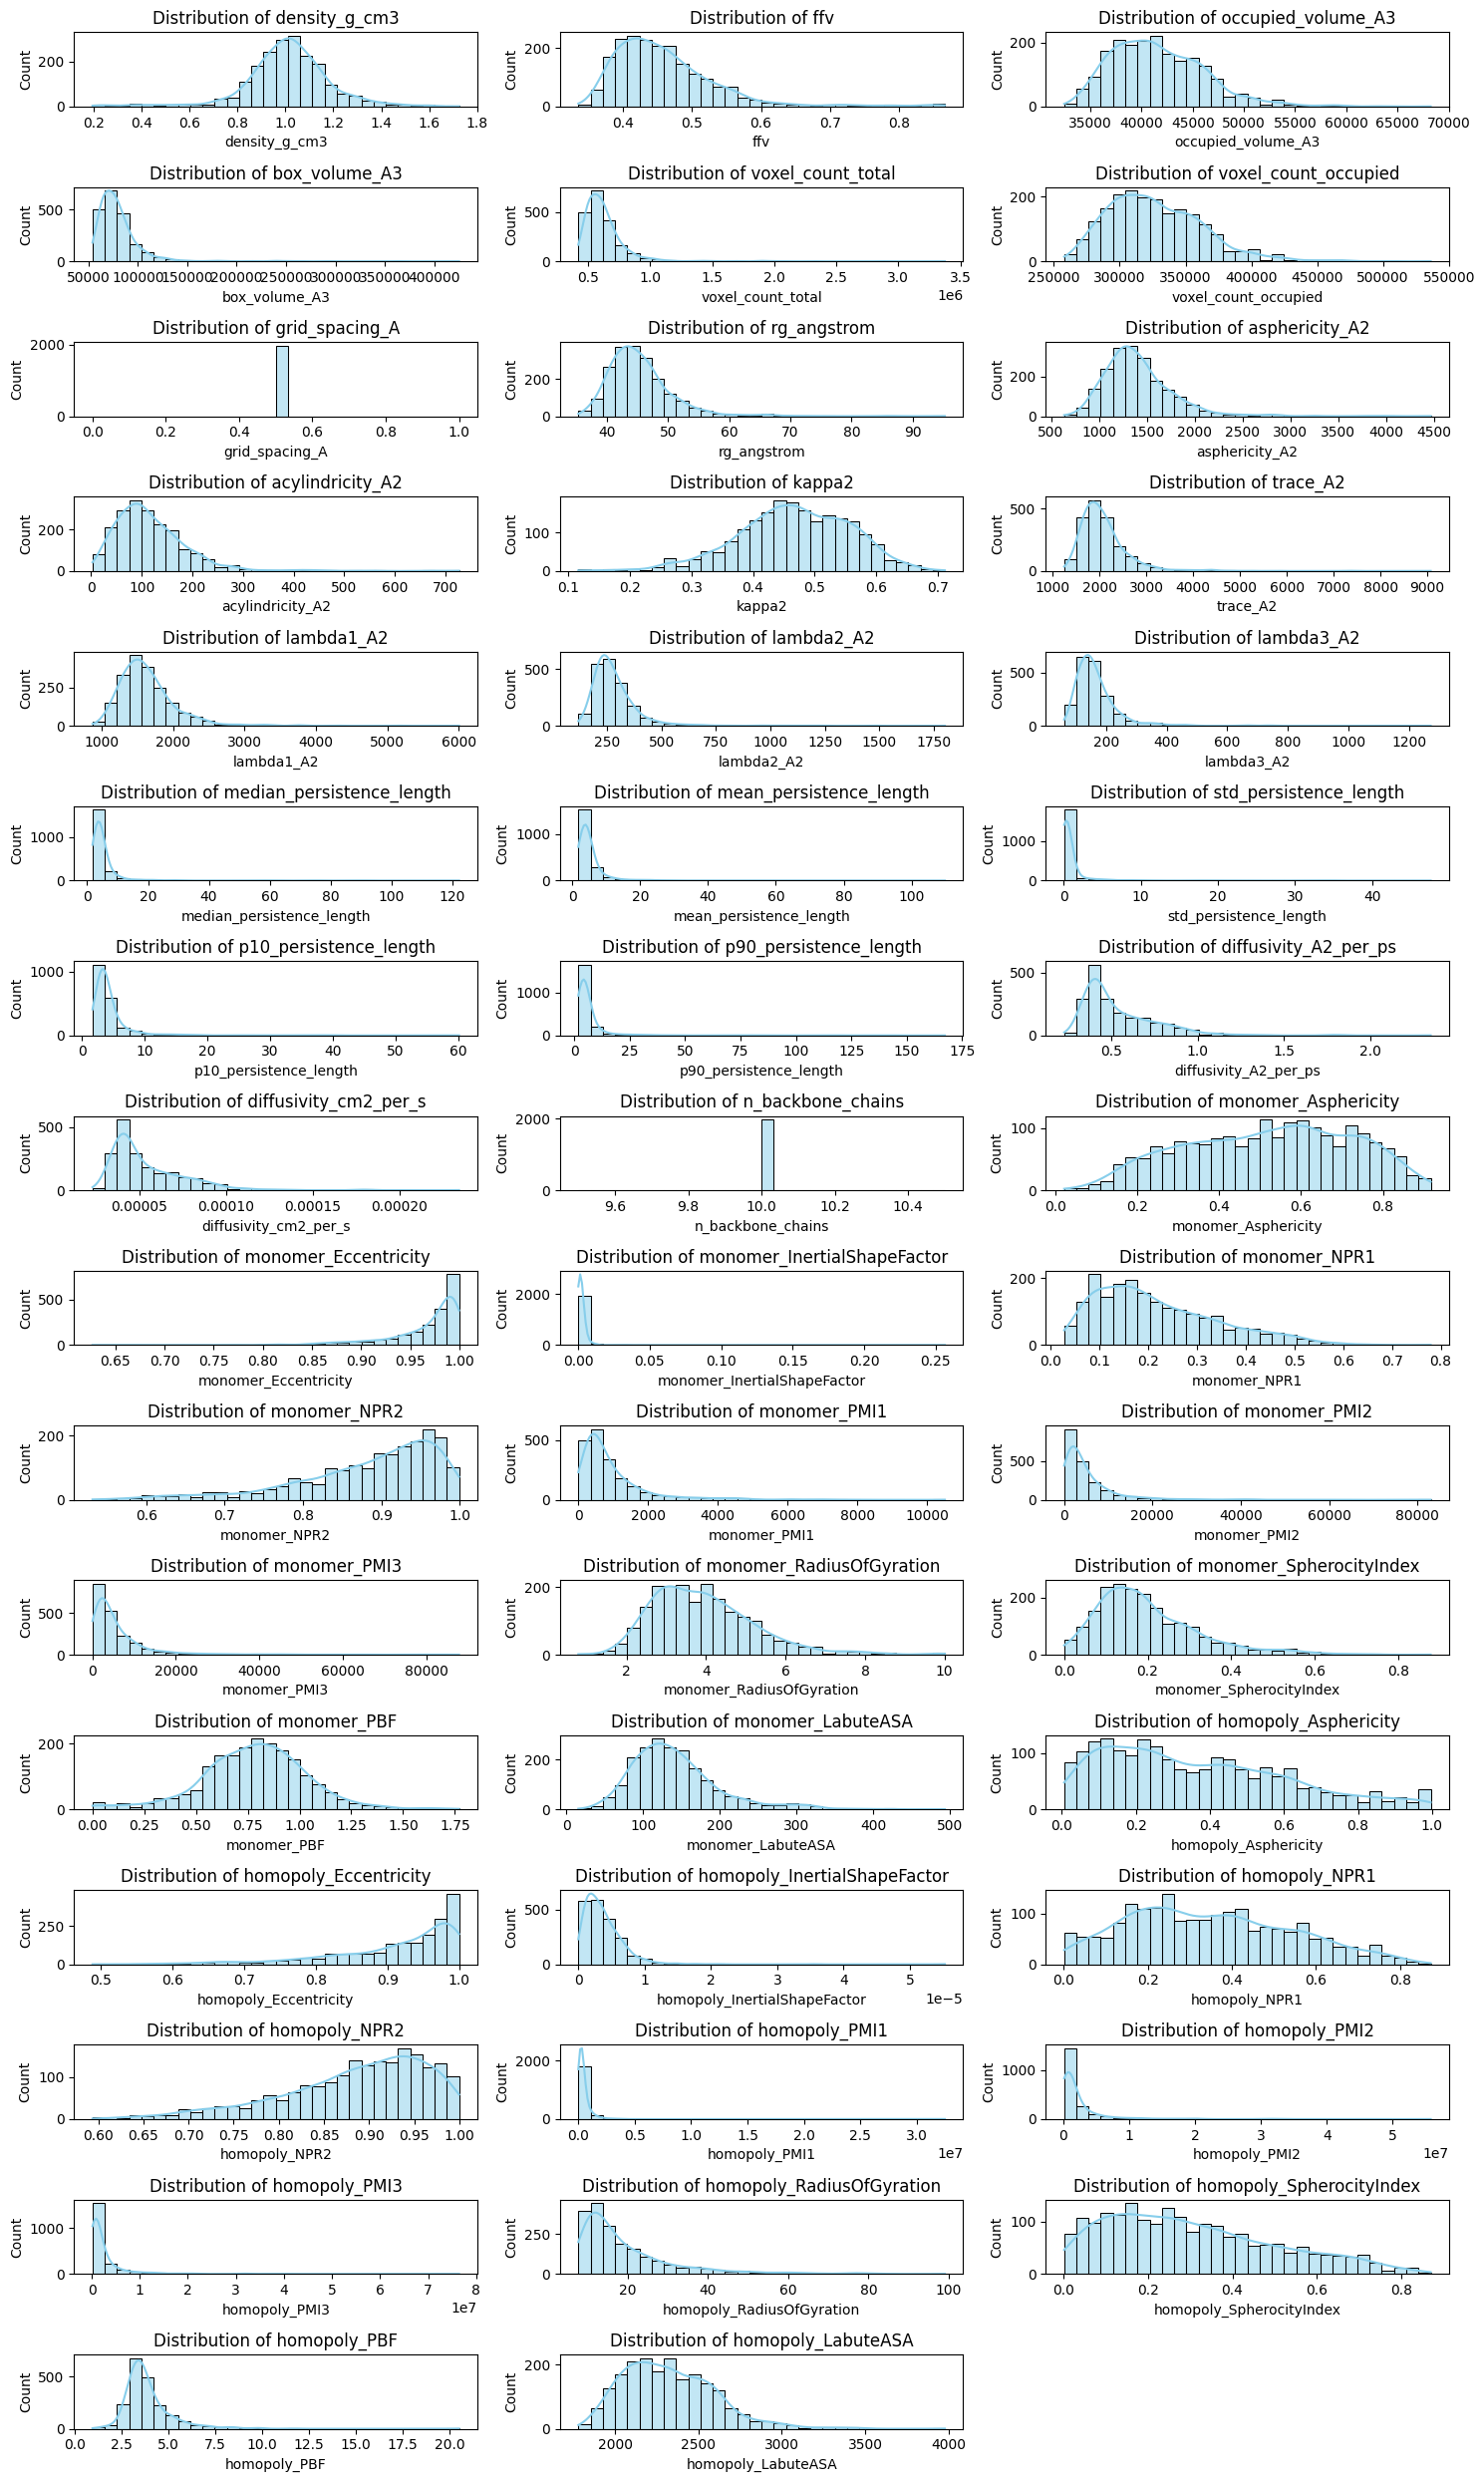

In [9]:
# List of numerical columns (excluding SMILES and selection)
numerical_cols = df.drop(columns=['SMILES', 'selection']).select_dtypes(include=['float64', 'int64']).columns

# 1. Distribution plots for all numerical columns
plt.figure(figsize=(15, 25))
for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols)//3 + 1, 3, i+1)
    sns.histplot(df[col], kde=True, color='skyblue', bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

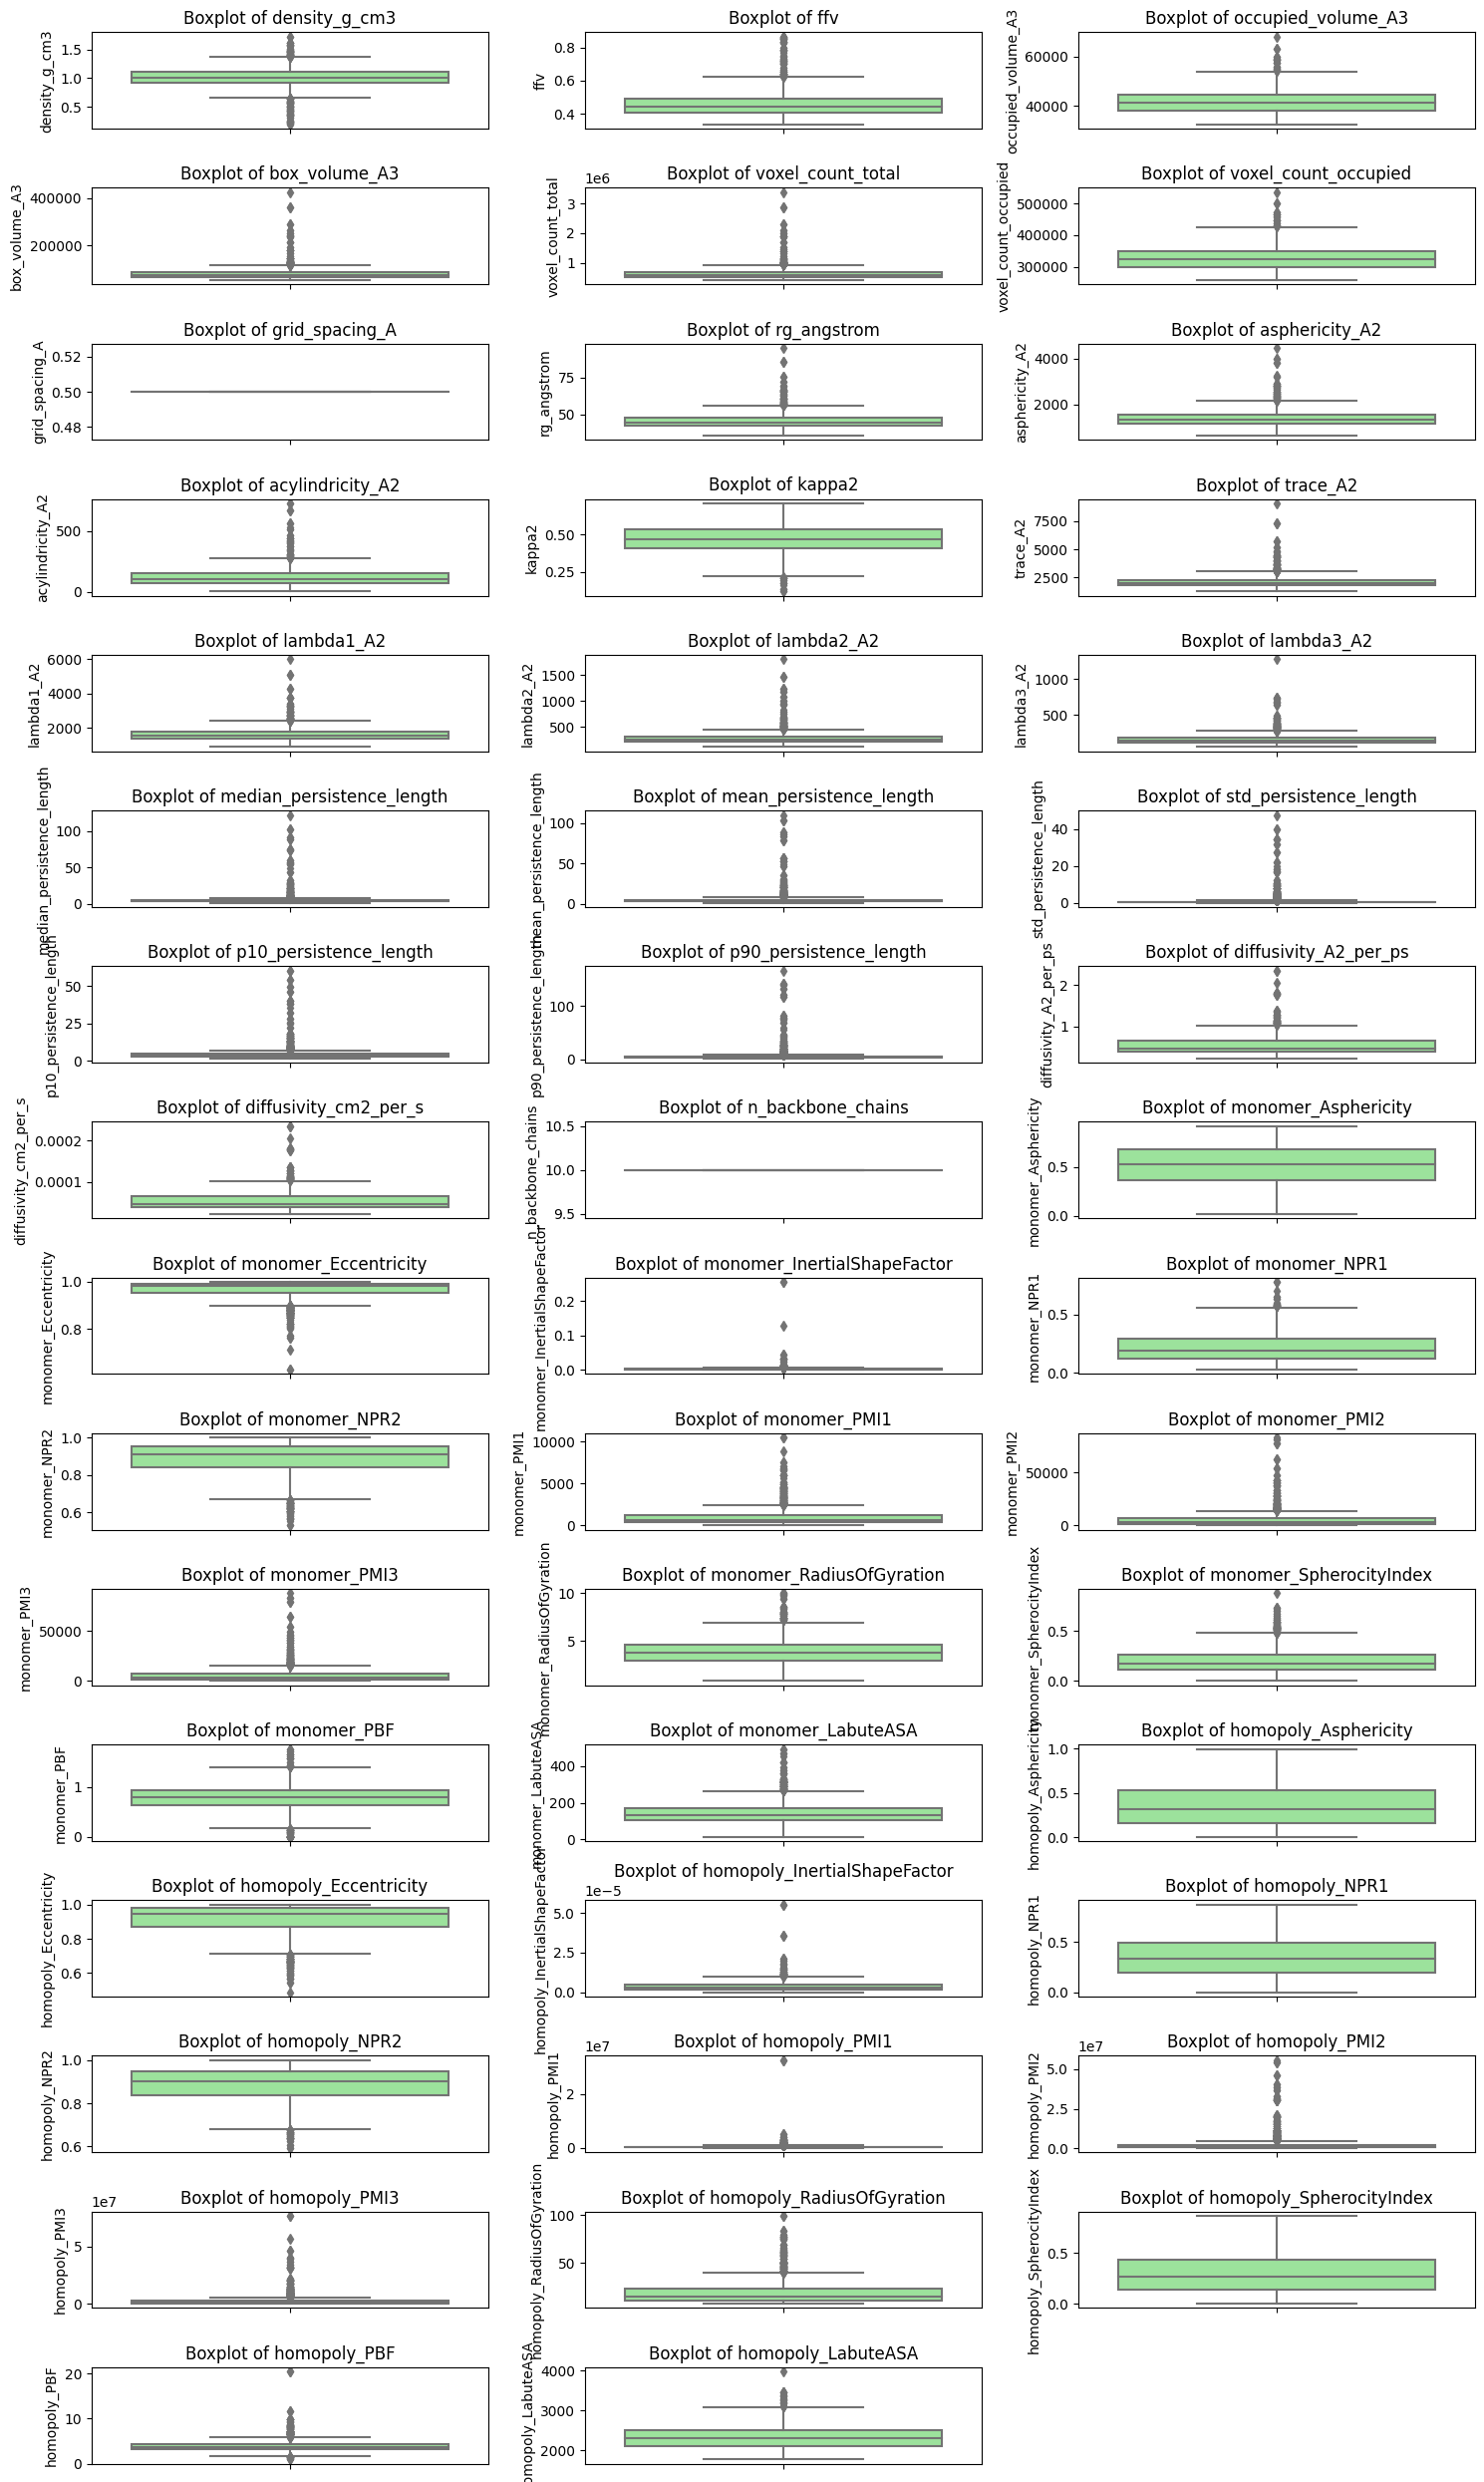

In [10]:
# 2. Boxplots for all numerical columns (to check outliers)
plt.figure(figsize=(15, 25))
for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols)//3 + 1, 3, i+1)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

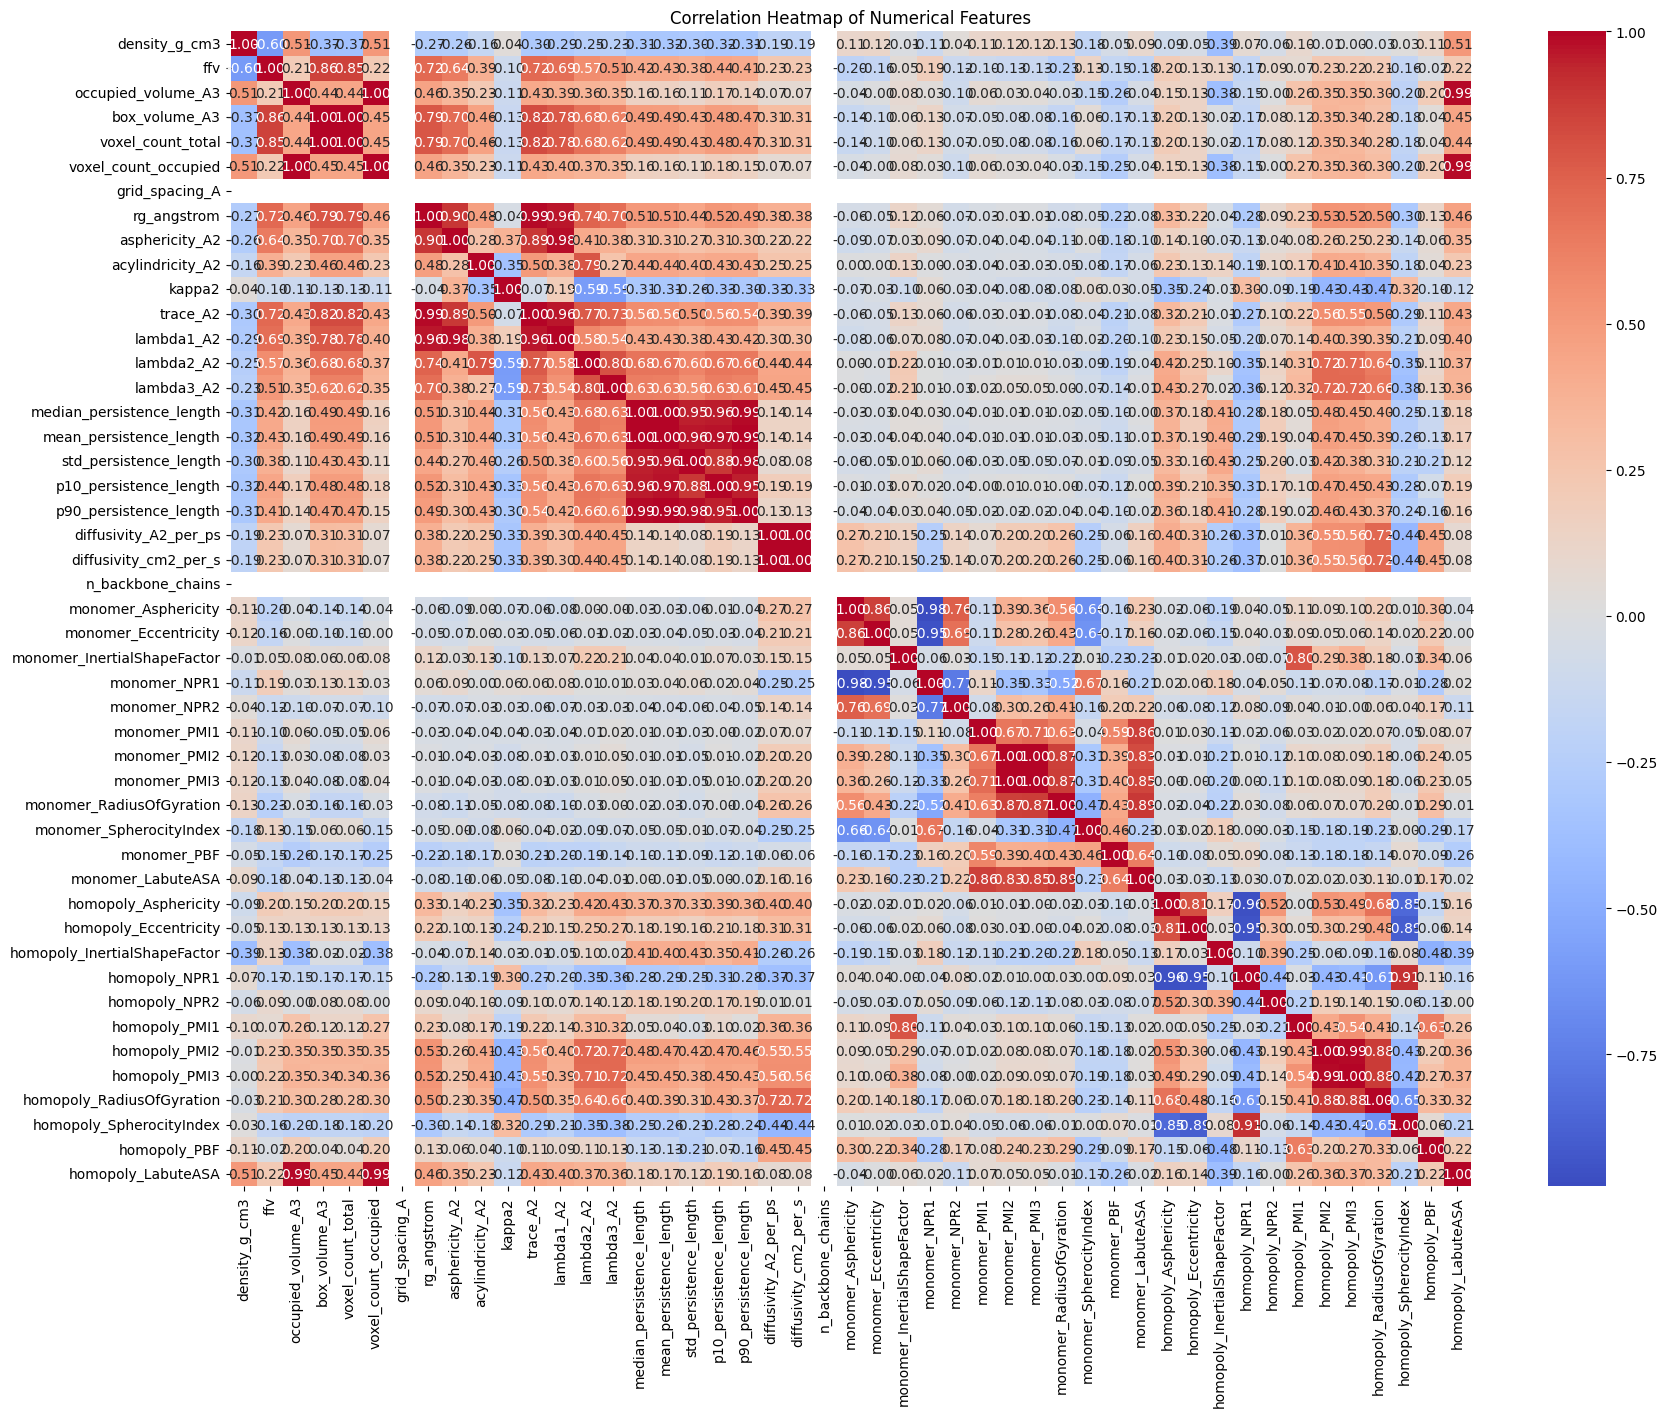

In [11]:
# 3. Correlation heatmap
plt.figure(figsize=(20, 15))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

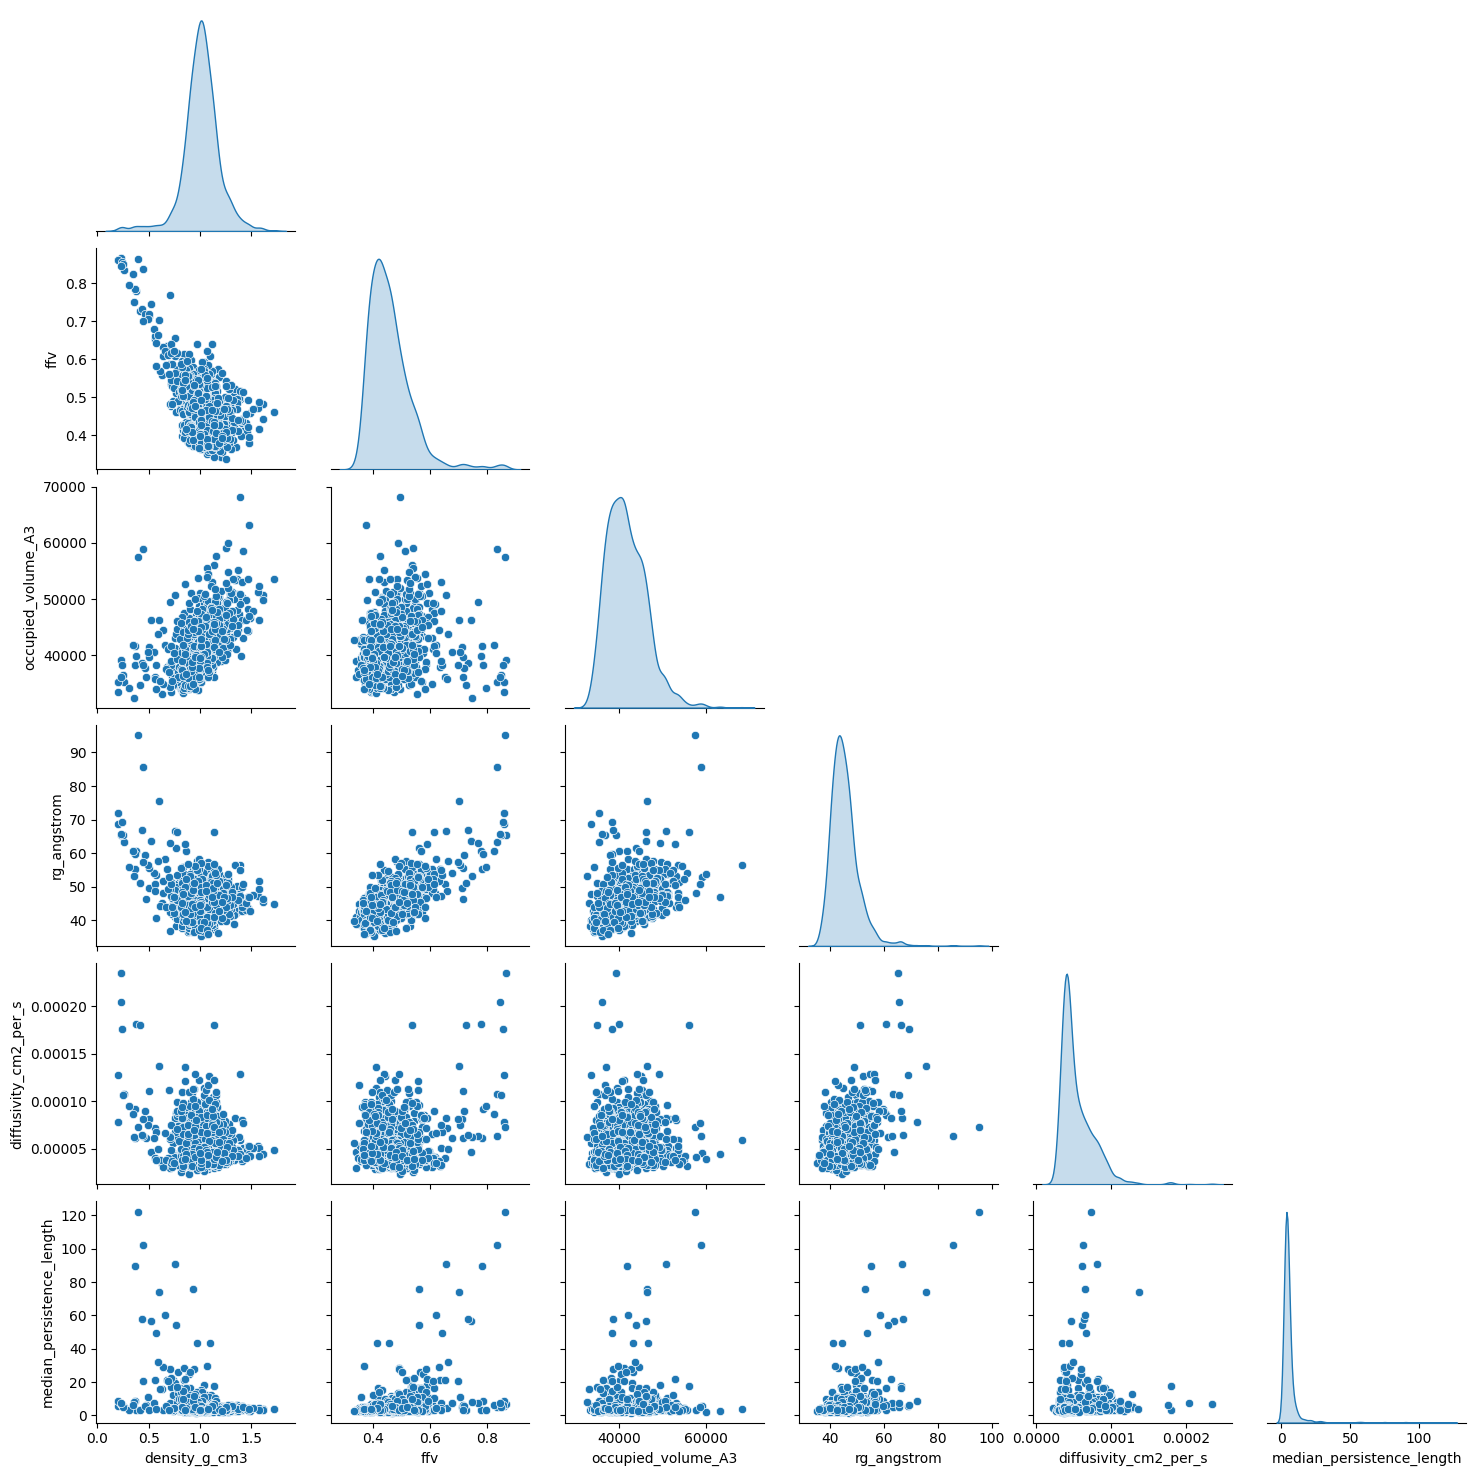

In [12]:
# 4. Pairplots for selected key features (avoid plotting all due to large number)
key_features = ['density_g_cm3', 'ffv', 'occupied_volume_A3', 'rg_angstrom', 
                'diffusivity_cm2_per_s', 'median_persistence_length']
sns.pairplot(df[key_features], diag_kind='kde', corner=True)
plt.show()

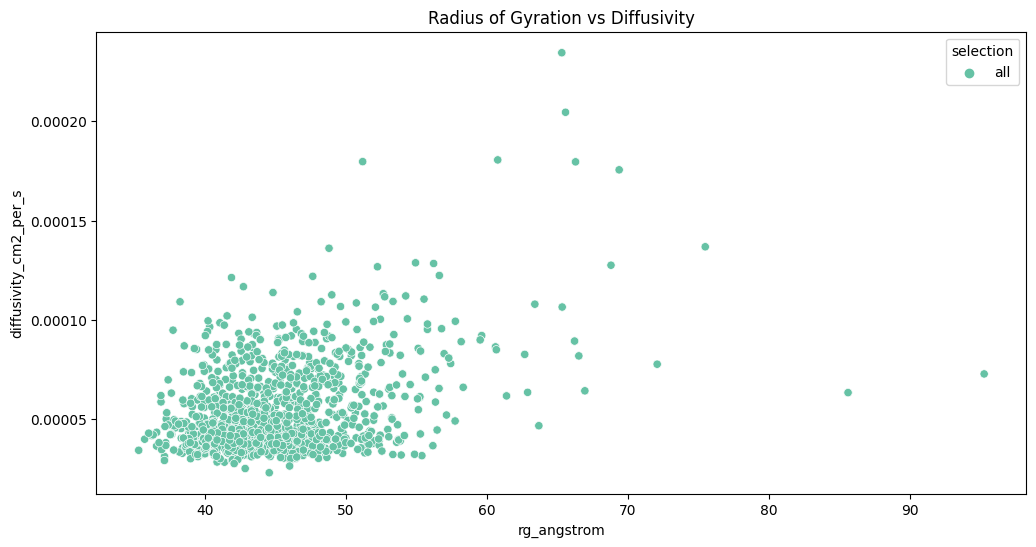

In [13]:
# 5. Scatter plots for relationships of interest
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='rg_angstrom', y='diffusivity_cm2_per_s', hue='selection', palette='Set2')
plt.title('Radius of Gyration vs Diffusivity')
plt.show()

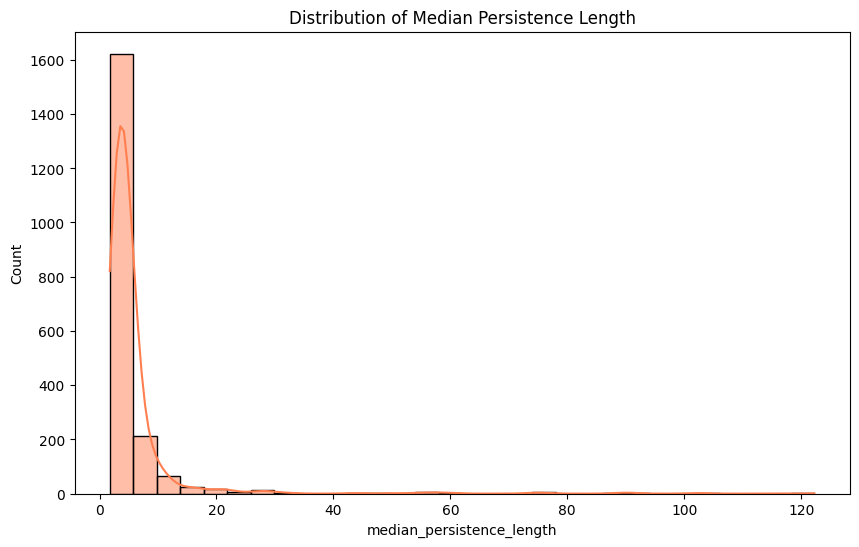

In [14]:
# 6. Distribution of persistence lengths
plt.figure(figsize=(10,6))
sns.histplot(df['median_persistence_length'], bins=30, kde=True, color='coral')
plt.title('Distribution of Median Persistence Length')
plt.show()

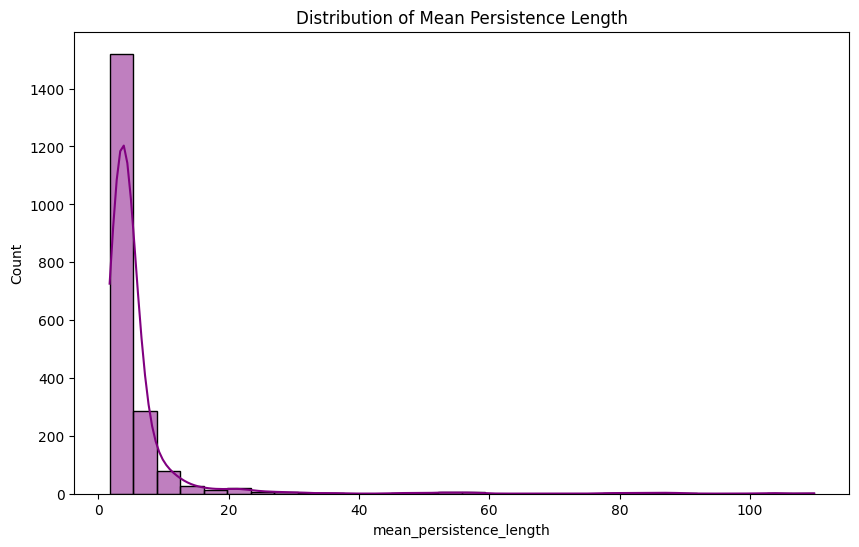

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(df['mean_persistence_length'], bins=30, kde=True, color='purple')
plt.title('Distribution of Mean Persistence Length')
plt.show()

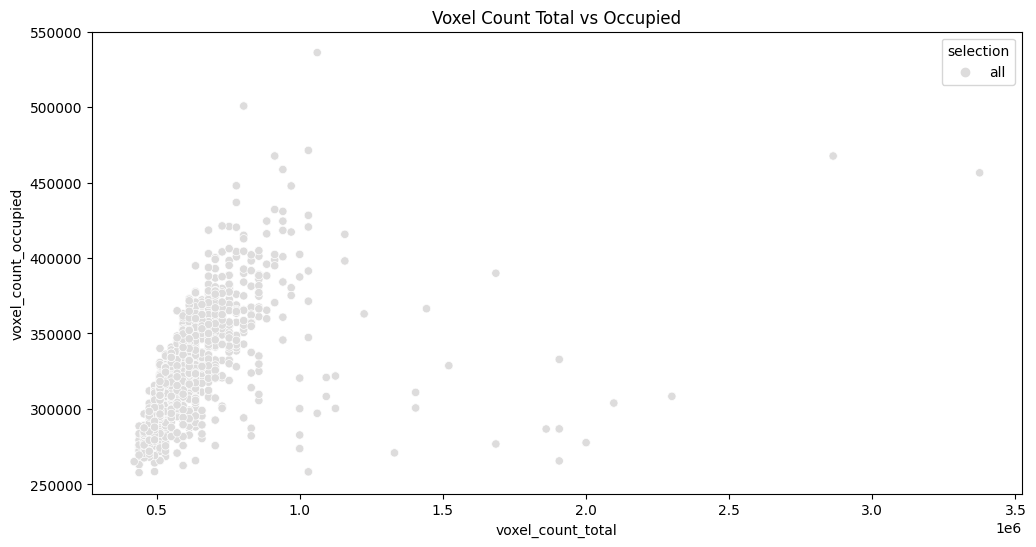

In [16]:
# 7. Visualizing voxel counts
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='voxel_count_total', y='voxel_count_occupied', hue='selection', palette='coolwarm')
plt.title('Voxel Count Total vs Occupied')
plt.show()

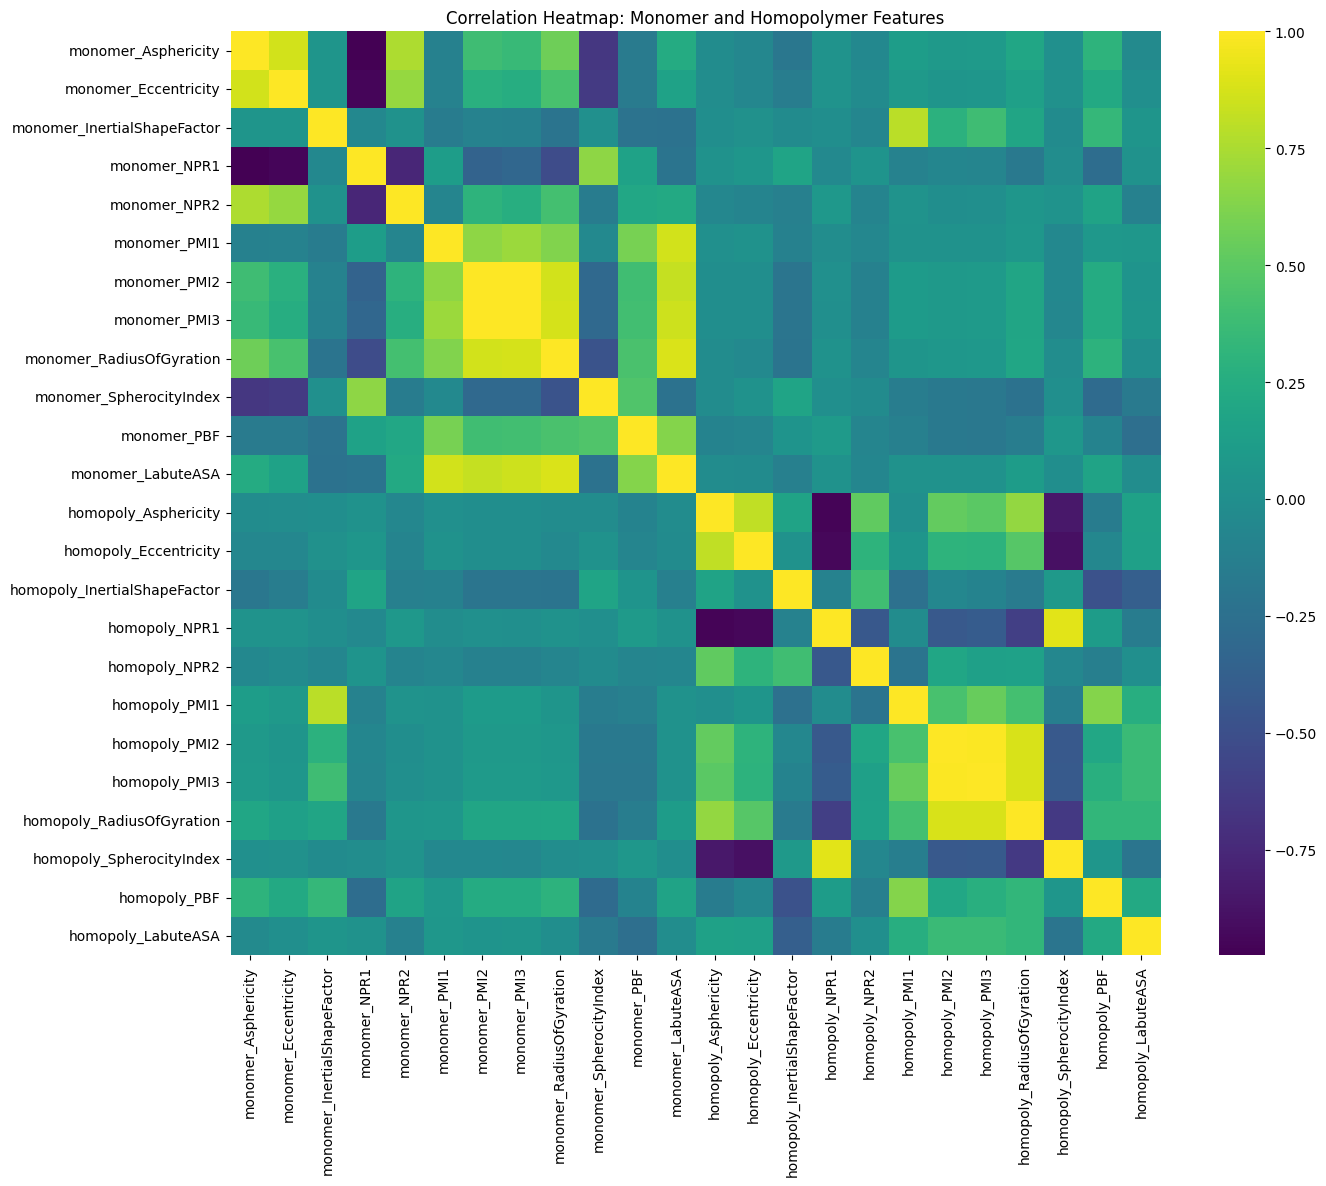

In [17]:
# 8. Monomer vs Homopolymer features correlation heatmap
monomer_cols = [col for col in df.columns if col.startswith('monomer')]
homopoly_cols = [col for col in df.columns if col.startswith('homopoly')]
plt.figure(figsize=(15, 12))
sns.heatmap(df[monomer_cols + homopoly_cols].corr(), annot=False, cmap='viridis')
plt.title('Correlation Heatmap: Monomer and Homopolymer Features')
plt.show()

## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

In [19]:
target = 'diffusivity_cm2_per_s'
X = df.drop(columns=['SMILES', target])
y = df[target]

categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=200),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42, n_estimators=200),
    'Support Vector Regressor': SVR()
}

In [21]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred) * 100  # percentage
    results.append({'Model': name, 'R2 (%)': r2, 'RMSE': rmse})

In [22]:
results_df = pd.DataFrame(results).sort_values(by='R2 (%)', ascending=False)
print(results_df)

                      Model       R2 (%)          RMSE
0         Linear Regression   100.000000  2.863287e-17
1          Ridge Regression    99.999803  2.877966e-08
5         Gradient Boosting    99.993458  1.658945e-07
3             Decision Tree    99.991777  1.859861e-07
4             Random Forest    99.962572  3.967893e-07
2          Lasso Regression    -0.443664  2.055526e-05
6  Support Vector Regressor -1354.536952  7.822113e-05


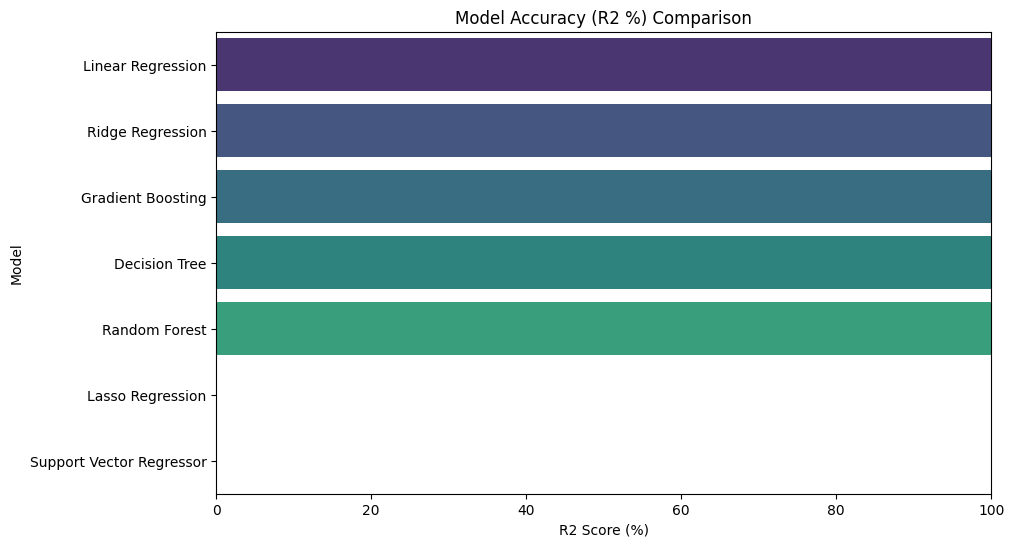

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x='R2 (%)', y='Model', palette='viridis')
plt.title('Model Accuracy (R2 %) Comparison')
plt.xlabel('R2 Score (%)')
plt.ylabel('Model')
plt.xlim(0, 100)
plt.show()

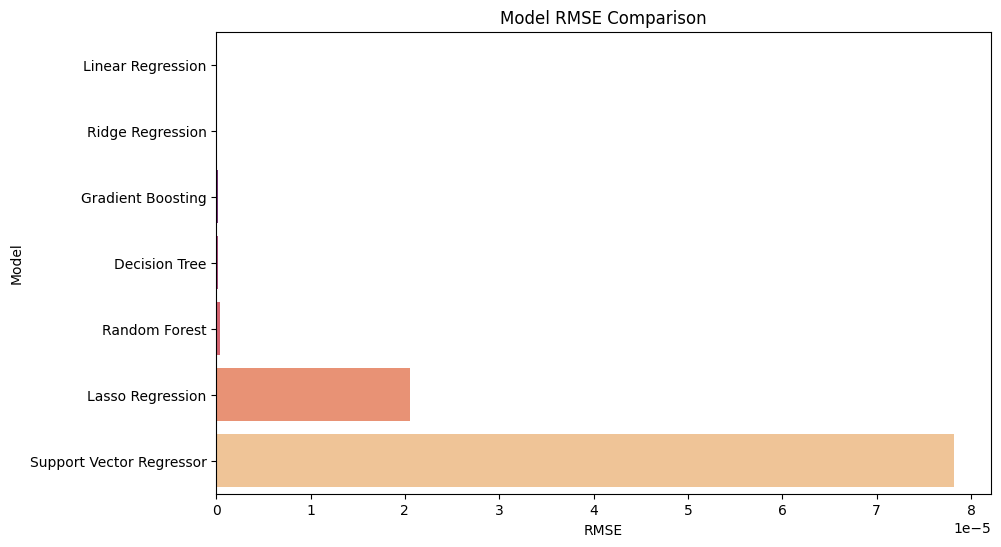

In [24]:
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x='RMSE', y='Model', palette='magma')
plt.title('Model RMSE Comparison')
plt.xlabel('RMSE')
plt.ylabel('Model')
plt.show()

## Thank you...pls upvote!!!!